# Linear regression model for house price prediction


### Imports

In [18]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv('data.csv')

In [20]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [21]:
data = data.dropna()

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [23]:
data.drop(columns = ['date','statezip','country'], inplace = True)

In [24]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond


In [25]:
data['house_age'] = 2026 - data['yr_built']
data.drop(columns = ['yr_built'], inplace = True)

data['renovation_age'] = np.where(data['yr_renovated'] > 0, 2026 - data['yr_renovated'], 0)
data.drop(columns = ['yr_renovated'], inplace = True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           4600 non-null   float64
 1   bedrooms        4600 non-null   float64
 2   bathrooms       4600 non-null   float64
 3   sqft_living     4600 non-null   int64  
 4   sqft_lot        4600 non-null   int64  
 5   floors          4600 non-null   float64
 6   waterfront      4600 non-null   int64  
 7   view            4600 non-null   int64  
 8   condition       4600 non-null   int64  
 9   sqft_above      4600 non-null   int64  
 10  sqft_basement   4600 non-null   int64  
 11  street          4600 non-null   object 
 12  city            4600 non-null   object 
 13  house_age       4600 non-null   int64  
 14  renovation_age  4600 non-null   int64  
dtypes: float64(4), int64(9), object(2)
memory usage: 539.2+ KB


In [26]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,street,city,house_age,renovation_age
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,18810 Densmore Ave N,Shoreline,71,21
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,709 W Blaine St,Seattle,105,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,26206-26214 143rd Ave SE,Kent,60,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,857 170th Pl NE,Bellevue,63,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,9105 170th Ave NE,Redmond,50,34


In [27]:
data.head(20)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,street,city,house_age,renovation_age
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,18810 Densmore Ave N,Shoreline,71,21
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,709 W Blaine St,Seattle,105,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,26206-26214 143rd Ave SE,Kent,60,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,857 170th Pl NE,Bellevue,63,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,9105 170th Ave NE,Redmond,50,34
5,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,522 NE 88th St,Seattle,88,32
6,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,2616 174th Ave NE,Redmond,50,0
7,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,23762 SE 253rd Pl,Maple Valley,37,0
8,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,46611-46625 SE 129th St,North Bend,41,0
9,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,6811 55th Ave NE,Seattle,81,16


In [28]:
data = data[(data['price'] < 1000000) & (data['price'] > 100000)]

data = data[data['sqft_lot'] < 100000]

In [29]:
encoder = LabelEncoder()

data['street_encoded'] = encoder.fit_transform(data['street']) + 1
data['city_encoded'] = encoder.fit_transform(data['city']) + 1

data['sqft_per_bedroom'] = data['sqft_living'] / data['bedrooms'] 
data['bedrooms_per_bath'] = data['bedrooms'] / data['bathrooms']

data.drop(columns = ['city','street'], inplace = True)
data.head()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,house_age,renovation_age,street_encoded,city_encoded,sqft_per_bedroom,bedrooms_per_bath
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,21,1377,37,446.666667,2.000000
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,2062,19,643.333333,1.500000
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,3808,4,666.666667,1.333333
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,34,3891,32,485.000000,1.600000
5,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,88,32,3144,36,440.000000,2.000000


In [30]:
data

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,house_age,renovation_age,street_encoded,city_encoded,sqft_per_bedroom,bedrooms_per_bath
0,313000.000000,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,21,1377,37,446.666667,2.000000
2,342000.000000,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,2062,19,643.333333,1.500000
3,420000.000000,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,3808,4,666.666667,1.333333
4,550000.000000,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,34,3891,32,485.000000,1.600000
5,490000.000000,2.0,1.00,880,6380,1.0,0,0,3,880,0,88,32,3144,36,440.000000,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,72,47,3078,36,503.333333,1.714286
4596,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,43,17,873,4,486.666667,1.200000
4597,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,17,0,3600,33,1003.333333,1.200000
4598,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,52,0,3123,36,522.500000,2.000000


In [31]:
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,house_age,renovation_age,street_encoded,city_encoded,sqft_per_bedroom,bedrooms_per_bath
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,21,1377,37,446.666667,2.000000
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,2062,19,643.333333,1.500000
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,3808,4,666.666667,1.333333
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,34,3891,32,485.000000,1.600000
5,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,88,32,3144,36,440.000000,2.000000


In [ ]:
data = pd.get_dummies(data, columns = ['city_encoded','street_encoded'], drop_first = True)

In [32]:
X = data.drop(columns = ['price'])
Y = data['price']

In [33]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,house_age,renovation_age,street_encoded,city_encoded,sqft_per_bedroom,bedrooms_per_bath
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,71,21,1377,37,446.666667,2.000000
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,60,0,2062,19,643.333333,1.500000
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,63,0,3808,4,666.666667,1.333333
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,50,34,3891,32,485.000000,1.600000
5,2.0,1.00,880,6380,1.0,0,0,3,880,0,88,32,3144,36,440.000000,2.000000


In [38]:
data.head()

street_encoded
1    309620.0
2    625000.0
3    600000.0
4    460000.0
5    575000.0
Name: price, dtype: float64

In [40]:
street_names = data.groupby('street_encoded')['price'].mean()

KeyError: 'Column not found: price'

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15)

In [ ]:
model = linear_model.LinearRegression()

In [ ]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
Y_pred = model.predict(X_test)

In [ ]:
print("coef",model.coef_)
print("intercept",model.intercept_)
print('r2_score',r2_score(Y_test, Y_pred))
print('mean_squared_error',mean_squared_error(Y_test, Y_pred))

coef [-5.65772764e+03  1.45115495e+04  5.46882534e+01 ... -1.02382986e+05
 -1.36390331e+05  0.00000000e+00]
intercept 179360.48692180973
r2_score 0.6719373967139138
mean_squared_error 12304366268.383514


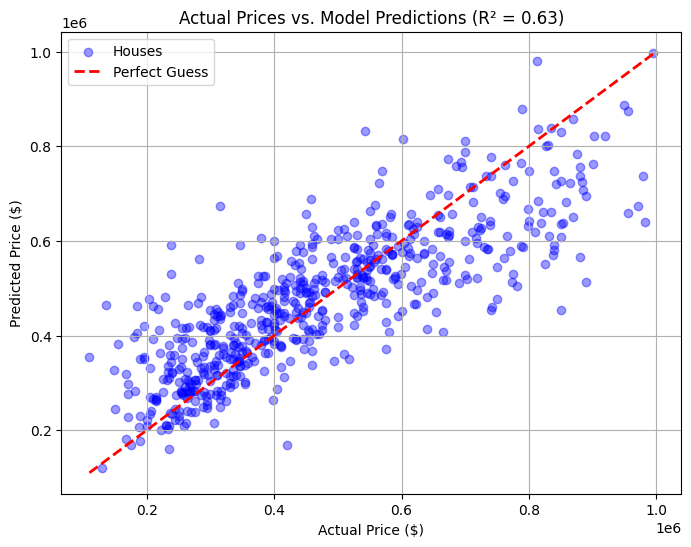

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, model.predict(X_test), alpha=0.4, color='blue', label='Houses')

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Guess')

#label
plt.title('Actual Prices vs. Model Predictions (R² = 0.63)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()

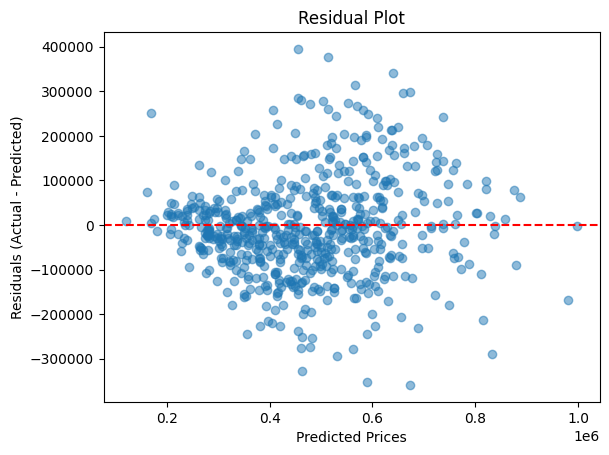

In [ ]:
residuals = Y_test - Y_pred

plt.scatter(Y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()